# 07 — Temporal Anomalies + Trend Decomposition
**Project:** Spatial–Temporal Analysis and Demand Forecasting of Ride-Hailing Mobility

**Purpose:** Automated temporal analysis on hourly demand per zone — two complementary layers:
* **ADTK** detects 5 anomaly types (spike, drop, level shift, volatility shift, seasonal deviation) without manual threshold tuning
* **Prophet** decomposes each series into trend, daily seasonality, weekly seasonality, holiday effects, and changepoints

Together they answer: *"When did demand behave unusually, and why is the baseline drifting?"*

**Output:**
* `temporal_anomalies` hypertable — one row per detected event
* `trend_decomposition` hypertable — one row per zone per hour (components)
* Visualizations in `outputs/temporal/`

**Tables used:** `hourly_demand`, `taxi_zones`  →  writes `temporal_anomalies`, `trend_decomposition`

## 0 · Setup

In [5]:
!pip install adtk prophet sqlalchemy psycopg2-binary -q

In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine, text

from adtk.data import validate_series
from adtk.detector import (
    ThresholdAD,
    QuantileAD,
    LevelShiftAD,
    VolatilityShiftAD,
    SeasonalAD,
)

from prophet import Prophet
from prophet.make_holidays import make_holidays_df

warnings.filterwarnings('ignore')
# Prophet is noisy — silence its cmdstanpy logger
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
ANOMALY_COLORS = {
    'spike':             '#DC2626',
    'drop':              '#2563EB',
    'level_shift':       '#D97706',
    'volatility_shift':  '#7C3AED',
    'seasonal_deviation':'#16A34A',
}

os.makedirs('outputs/temporal', exist_ok=True)
print('Setup complete.')

Setup complete.


In [7]:
PG_HOST = '0.tcp.ngrok.io'
PG_PORT = 18545
PG_DB   = 'rides'
PG_USER = 'rides'
PG_PASS = 'rides'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True,
)

with engine.connect() as conn:
    n = conn.execute(text('SELECT COUNT(*) FROM hourly_demand')).scalar()
    span = conn.execute(text(
        'SELECT MIN(time_bucket), MAX(time_bucket) FROM hourly_demand'
    )).fetchone()
    print(f'hourly_demand rows: {n:,}')
    print(f'Time span:          {span[0]}  →  {span[1]}')

hourly_demand rows: 181,571
Time span:          2026-05-11 00:00:00+00:00  →  2026-06-09 23:00:00+00:00


In [8]:
# Backfill hourly_demand from trip_events
with engine.connect() as conn:
    conn.execute(text("TRUNCATE hourly_demand"))
    conn.execute(text("""
        INSERT INTO hourly_demand
            (time_bucket, zone_id, pickup_count, dropoff_count, avg_trip_miles, avg_trip_time)
        SELECT
            date_trunc('hour', pickup_datetime),
            pu_zone_id,
            COUNT(*),
            0,
            AVG(trip_miles),
            AVG(trip_time_min)
        FROM trip_events
        WHERE pu_zone_id IS NOT NULL
        GROUP BY 1, 2
    """))
    conn.commit()

print(pd.read_sql("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT time_bucket) AS hours,
       MIN(time_bucket), MAX(time_bucket),
       EXTRACT(EPOCH FROM (MAX(time_bucket)-MIN(time_bucket)))/86400 AS days
FROM hourly_demand
""", engine).T)

                               0
rows                      181571
hours                        720
min    2026-05-11 00:00:00+00:00
max    2026-06-09 23:00:00+00:00
days                   29.958333


## 1 · Load Top-Zone Hourly Demand

Same 10 zones we forecast in notebook 06 — keeps the thesis story consistent and lets us cross-reference: anomalies should correlate with poor forecast performance.

In [9]:
TOP_N = 10

top_zones = pd.read_sql(f"""
SELECT hd.zone_id, z.zone_name, z.borough, SUM(hd.pickup_count) AS total_pickups
FROM hourly_demand hd JOIN taxi_zones z USING(zone_id)
WHERE z.borough != 'Unknown'
GROUP BY hd.zone_id, z.zone_name, z.borough
ORDER BY total_pickups DESC LIMIT {TOP_N}
""", engine)
zone_ids = top_zones['zone_id'].tolist()
zone_id_csv = ','.join(map(str, zone_ids))
print(top_zones.to_string(index=False))

 zone_id                 zone_name   borough  total_pickups
     138         LaGuardia Airport    Queens         393026
     132               JFK Airport    Queens         364605
      79              East Village Manhattan         265541
      61       Crown Heights North  Brooklyn         254632
     230 Times Sq/Theatre District Manhattan         241889
     161            Midtown Center Manhattan         237328
     231      TriBeCa/Civic Center Manhattan         234920
      68              East Chelsea Manhattan         218806
     246 West Chelsea/Hudson Yards Manhattan         217597
      76             East New York  Brooklyn         213514


In [10]:
demand_df = pd.read_sql(f"""
SELECT time_bucket, zone_id, pickup_count
FROM hourly_demand
WHERE zone_id IN ({zone_id_csv})
ORDER BY zone_id, time_bucket
""", engine, parse_dates=['time_bucket'])

wide = (demand_df.pivot(index='time_bucket', columns='zone_id', values='pickup_count')
                  .asfreq('h'))
# Zeros from gap periods should be NaN, not 0 — they're "no data", not "no demand"
wide = wide.replace(0, np.nan)
# Forward-fill only short legitimate gaps (≤2h)
wide = wide.ffill(limit=2)
# Drop hours where ALL zones are NaN (pipeline outage windows)
all_nan_hours = wide.isna().all(axis=1)
print(f'Dropping {all_nan_hours.sum()} pipeline-outage hours')
wide = wide.loc[~all_nan_hours]
# For remaining NaN cells (a single zone missing some hours), zero is the safe fill
wide = wide.fillna(0)
print(f'Wide matrix: {wide.shape}')

Dropping 0 pipeline-outage hours
Wide matrix: (720, 10)


## 2 · ADTK Anomaly Detection

Five detectors, each catches a different failure mode:

| Detector | What it catches | How it scores |
|---|---|---|
| `ThresholdAD` | Spikes/drops above absolute bounds | distance / threshold |
| `QuantileAD` | Values outside global 1st/99th percentile | quantile-distance |
| `LevelShiftAD` | Persistent baseline change | window-mean delta |
| `VolatilityShiftAD` | Change in variability | window-std delta |
| `SeasonalAD` | Deviation from learned 24h seasonal pattern | residual after seasonal fit |

ADTK gives binary labels (anomaly / not). We compute a continuous `anomaly_score` per detector type for the `temporal_anomalies` table so Grafana can rank events by severity.

In [11]:
def detect_anomalies_for_zone(zid, series):
    """Run all 5 ADTK detectors on one zone. Returns list of anomaly records."""
    records = []
    if series.sum() < 50 or series.dropna().nunique() < 5:
        return records   # skip near-empty zones

    s = validate_series(series)

    # 1. ThresholdAD — absolute spikes / drops
    #    Use 95th percentile as upper, 5th as lower
    high = float(s.quantile(0.95))
    low  = float(s.quantile(0.05))
    thr_ad = ThresholdAD(high=high * 1.5, low=max(0, low * 0.3))
    thr_flags = thr_ad.detect(s)
    for t, flag in thr_flags.dropna().items():
        if flag:
            val = float(s.loc[t])
            atype = 'spike' if val > high else 'drop'
            expected = high if atype == 'spike' else low
            score = abs(val - expected) / max(expected, 1.0)
            records.append({
                'detected_at': t, 'zone_id': zid, 'anomaly_type': atype,
                'anomaly_score': float(score), 'demand_value': val,
                'expected_value': float(expected), 'is_anomaly': True,
            })

    # 2. QuantileAD — distributional outliers (different signal than threshold)
    try:
        q_ad = QuantileAD(high=0.99, low=0.01)
        q_flags = q_ad.fit_detect(s)
        median = float(s.median())
        for t, flag in q_flags.dropna().items():
            if flag:
                val = float(s.loc[t])
                records.append({
                    'detected_at': t, 'zone_id': zid,
                    'anomaly_type': 'seasonal_deviation',
                    'anomaly_score': float(abs(val - median) / max(median, 1.0)),
                    'demand_value': val, 'expected_value': median, 'is_anomaly': True,
                })
    except Exception:
        pass

    # 3. LevelShiftAD — persistent baseline change (24h window)
    try:
        ls_ad = LevelShiftAD(c=6.0, side='both', window=24)
        ls_flags = ls_ad.fit_detect(s)
        for t, flag in ls_flags.dropna().items():
            if flag:
                val = float(s.loc[t])
                window_mean = float(s.loc[:t].tail(24).mean())
                records.append({
                    'detected_at': t, 'zone_id': zid, 'anomaly_type': 'level_shift',
                    'anomaly_score': float(abs(val - window_mean) / max(window_mean, 1.0)),
                    'demand_value': val, 'expected_value': window_mean, 'is_anomaly': True,
                })
    except Exception:
        pass

    # 4. VolatilityShiftAD — change in variability
    try:
        vs_ad = VolatilityShiftAD(c=6.0, side='positive', window=24)
        vs_flags = vs_ad.fit_detect(s)
        for t, flag in vs_flags.dropna().items():
            if flag:
                val = float(s.loc[t])
                window_std = float(s.loc[:t].tail(24).std())
                records.append({
                    'detected_at': t, 'zone_id': zid, 'anomaly_type': 'volatility_shift',
                    'anomaly_score': float(window_std),
                    'demand_value': val, 'expected_value': float(s.loc[:t].tail(24).mean()),
                    'is_anomaly': True,
                })
    except Exception:
        pass

    # 5. SeasonalAD — deviation from learned 24h cycle
    #    Needs at least 2 full cycles to fit; will skip if insufficient
    try:
        if len(s) >= 48:
            sa = SeasonalAD(freq=24, c=3.0, side='both')
            sa_flags = sa.fit_detect(s)
            for t, flag in sa_flags.dropna().items():
                if flag:
                    val = float(s.loc[t])
                    hour = t.hour
                    # Expected = mean for that hour-of-day across history
                    expected = float(s[s.index.hour == hour].mean())
                    records.append({
                        'detected_at': t, 'zone_id': zid,
                        'anomaly_type': 'seasonal_deviation',
                        'anomaly_score': float(abs(val - expected) / max(expected, 1.0)),
                        'demand_value': val, 'expected_value': expected, 'is_anomaly': True,
                    })
    except Exception:
        pass

    return records

In [12]:
all_anomalies = []
for zid in zone_ids:
    series = wide[zid].astype(float)
    series.index.name = 'time'
    recs = detect_anomalies_for_zone(zid, series)
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    print(f'  zone {zid:3d} ({name[:25]:25s}): {len(recs)} anomalies')
    all_anomalies.extend(recs)

anom_df = pd.DataFrame(all_anomalies)
# Dedupe — multiple detectors can flag the same hour
if len(anom_df):
    anom_df = (anom_df.sort_values('anomaly_score', ascending=False)
                       .drop_duplicates(subset=['detected_at', 'zone_id', 'anomaly_type']))
print(f'\nTotal anomalies (deduped): {len(anom_df):,}')
print(f'By type:\n{anom_df["anomaly_type"].value_counts().to_string()}' if len(anom_df) else 'No anomalies')

  zone 138 (LaGuardia Airport        ): 18 anomalies
  zone 132 (JFK Airport              ): 19 anomalies
  zone  79 (East Village             ): 21 anomalies
  zone  61 (Crown Heights North      ): 22 anomalies
  zone 230 (Times Sq/Theatre District): 29 anomalies
  zone 161 (Midtown Center           ): 35 anomalies
  zone 231 (TriBeCa/Civic Center     ): 16 anomalies
  zone  68 (East Chelsea             ): 16 anomalies
  zone 246 (West Chelsea/Hudson Yards): 18 anomalies
  zone  76 (East New York            ): 22 anomalies

Total anomalies (deduped): 192
By type:
anomaly_type
seasonal_deviation    181
drop                   10
spike                   1


## 3 · Visualize Anomalies — Top 6 Zones

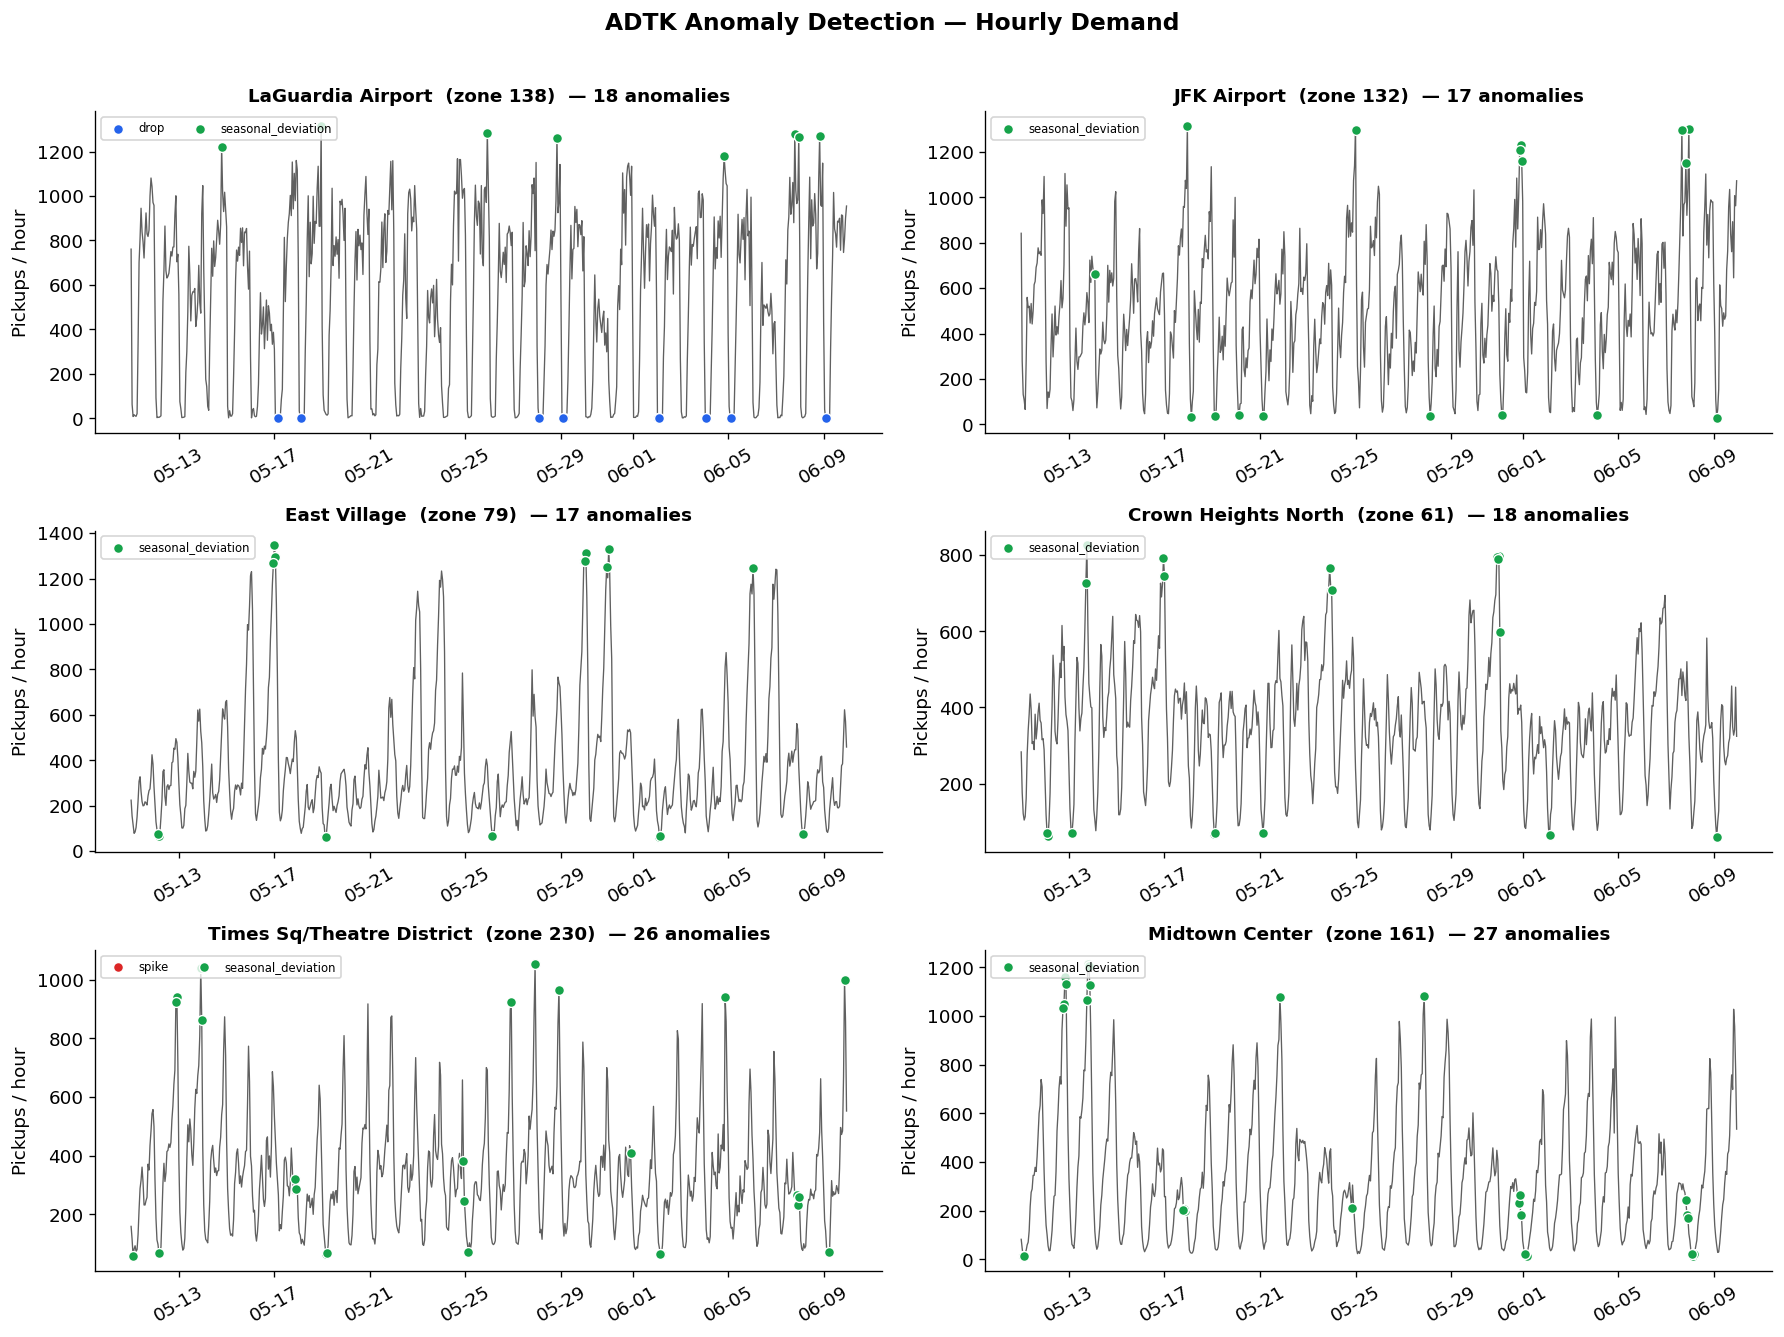

In [13]:
top6 = wide.sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 11))
for ax, zid in zip(axes.flat, top6):
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    series = wide[zid]
    ax.plot(series.index, series.values, color='#444', lw=0.8, alpha=0.85)

    # Overlay anomalies (skip cleanly if none detected)
    n_anom = 0
    if len(anom_df) and 'anomaly_type' in anom_df.columns:
        zone_anoms = anom_df[anom_df['zone_id'] == zid]
        for atype, color in ANOMALY_COLORS.items():
            sub = zone_anoms[zone_anoms['anomaly_type'] == atype]
            if len(sub):
                ax.scatter(sub['detected_at'], sub['demand_value'],
                           color=color, s=35, label=atype, zorder=3,
                           edgecolors='white', linewidths=0.8)
        n_anom = len(zone_anoms)

    ax.set_title(f'{name}  (zone {zid})  — {n_anom} anomalies',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Pickups / hour')
    if n_anom:
        ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('ADTK Anomaly Detection — Hourly Demand',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/temporal/01_adtk_anomalies.png', bbox_inches='tight', dpi=150)
plt.show()

## 4 · Prophet — Trend + Seasonality + Changepoints

Prophet decomposes each zone's demand into interpretable components. Unlike ARIMA, this isn't for forecasting — it's for explaining *why* demand looks the way it does.

Components extracted per hour per zone:
- **trend** — smoothed long-term direction
- **seasonal_daily** — hour-of-day pattern (morning rush, late-night lull)
- **seasonal_weekly** — day-of-week pattern (Friday peak, Sunday dip)
- **holiday_effect** — deviation on US federal holidays
- **changepoint_detected** — flag if the trend slope shifted near this hour
- **residual** — unexplained = actual − (trend + seasonals + holidays)

In [14]:
# Build US holiday calendar for the data span
years = list(range(wide.index.min().year, wide.index.max().year + 1))
holidays = make_holidays_df(year_list=years, country='US')
print(f'US holidays in span: {len(holidays)}')
print(holidays.head())

US holidays in span: 12
          ds                               holiday
0 2026-01-01                        New Year's Day
1 2026-05-25                          Memorial Day
2 2026-06-19  Juneteenth National Independence Day
3 2026-07-04                      Independence Day
4 2026-07-03           Independence Day (observed)


In [15]:
def decompose_zone(zid, series):
    """Fit Prophet, return per-hour decomposition records."""
    if series.sum() < 50 or len(series) < 48:
        return []

    df = pd.DataFrame({'ds': series.index, 'y': series.values})
    # Prophet needs naive datetimes (no tz)
    df['ds'] = df['ds'].dt.tz_localize(None) if df['ds'].dt.tz is not None else df['ds']

    m = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,
        holidays=holidays,
        changepoint_prior_scale=0.05,
    )
    m.fit(df)

    # Predict on the same dates → get decomposition
    fc = m.predict(df[['ds']])

    # Changepoints: dates where Prophet thinks the trend slope changed
    cp_dates = set(pd.to_datetime(m.changepoints).round('h'))

    records = []
    for i, row in fc.iterrows():
        ts = row['ds']
        ts_rounded = pd.Timestamp(ts).round('h')
        actual = float(df.iloc[i]['y'])
        trend = float(row['trend'])
        weekly = float(row.get('weekly', 0.0))
        daily = float(row.get('daily', 0.0))
        hol = float(row.get('holidays', 0.0))
        residual = actual - (trend + daily + weekly + hol)
        records.append({
            'analysis_time':         ts,
            'zone_id':               zid,
            'trend_value':           trend,
            'seasonal_daily':        daily,
            'seasonal_weekly':       weekly,
            'changepoint_detected':  ts_rounded in cp_dates,
            'holiday_effect':        hol,
            'residual':              residual,
        })
    return records

In [16]:
decomp_records = []
for zid in zone_ids:
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    series = wide[zid].astype(float)
    series.index.name = 'time'
    try:
        recs = decompose_zone(zid, series)
        decomp_records.extend(recs)
        print(f'  zone {zid:3d} ({name[:25]:25s}): {len(recs)} hours decomposed')
    except Exception as e:
        print(f'  zone {zid} ({name}): FAILED — {type(e).__name__}: {e}')

decomp_df = pd.DataFrame(decomp_records)
print(f'\nTotal decomposition rows: {len(decomp_df):,}')

  zone 138 (LaGuardia Airport        ): 720 hours decomposed
  zone 132 (JFK Airport              ): 720 hours decomposed
  zone  79 (East Village             ): 720 hours decomposed
  zone  61 (Crown Heights North      ): 720 hours decomposed
  zone 230 (Times Sq/Theatre District): 720 hours decomposed
  zone 161 (Midtown Center           ): 720 hours decomposed
  zone 231 (TriBeCa/Civic Center     ): 720 hours decomposed
  zone  68 (East Chelsea             ): 720 hours decomposed
  zone 246 (West Chelsea/Hudson Yards): 720 hours decomposed
  zone  76 (East New York            ): 720 hours decomposed

Total decomposition rows: 7,200


## 5 · Visualize Decomposition — Top 3 Zones

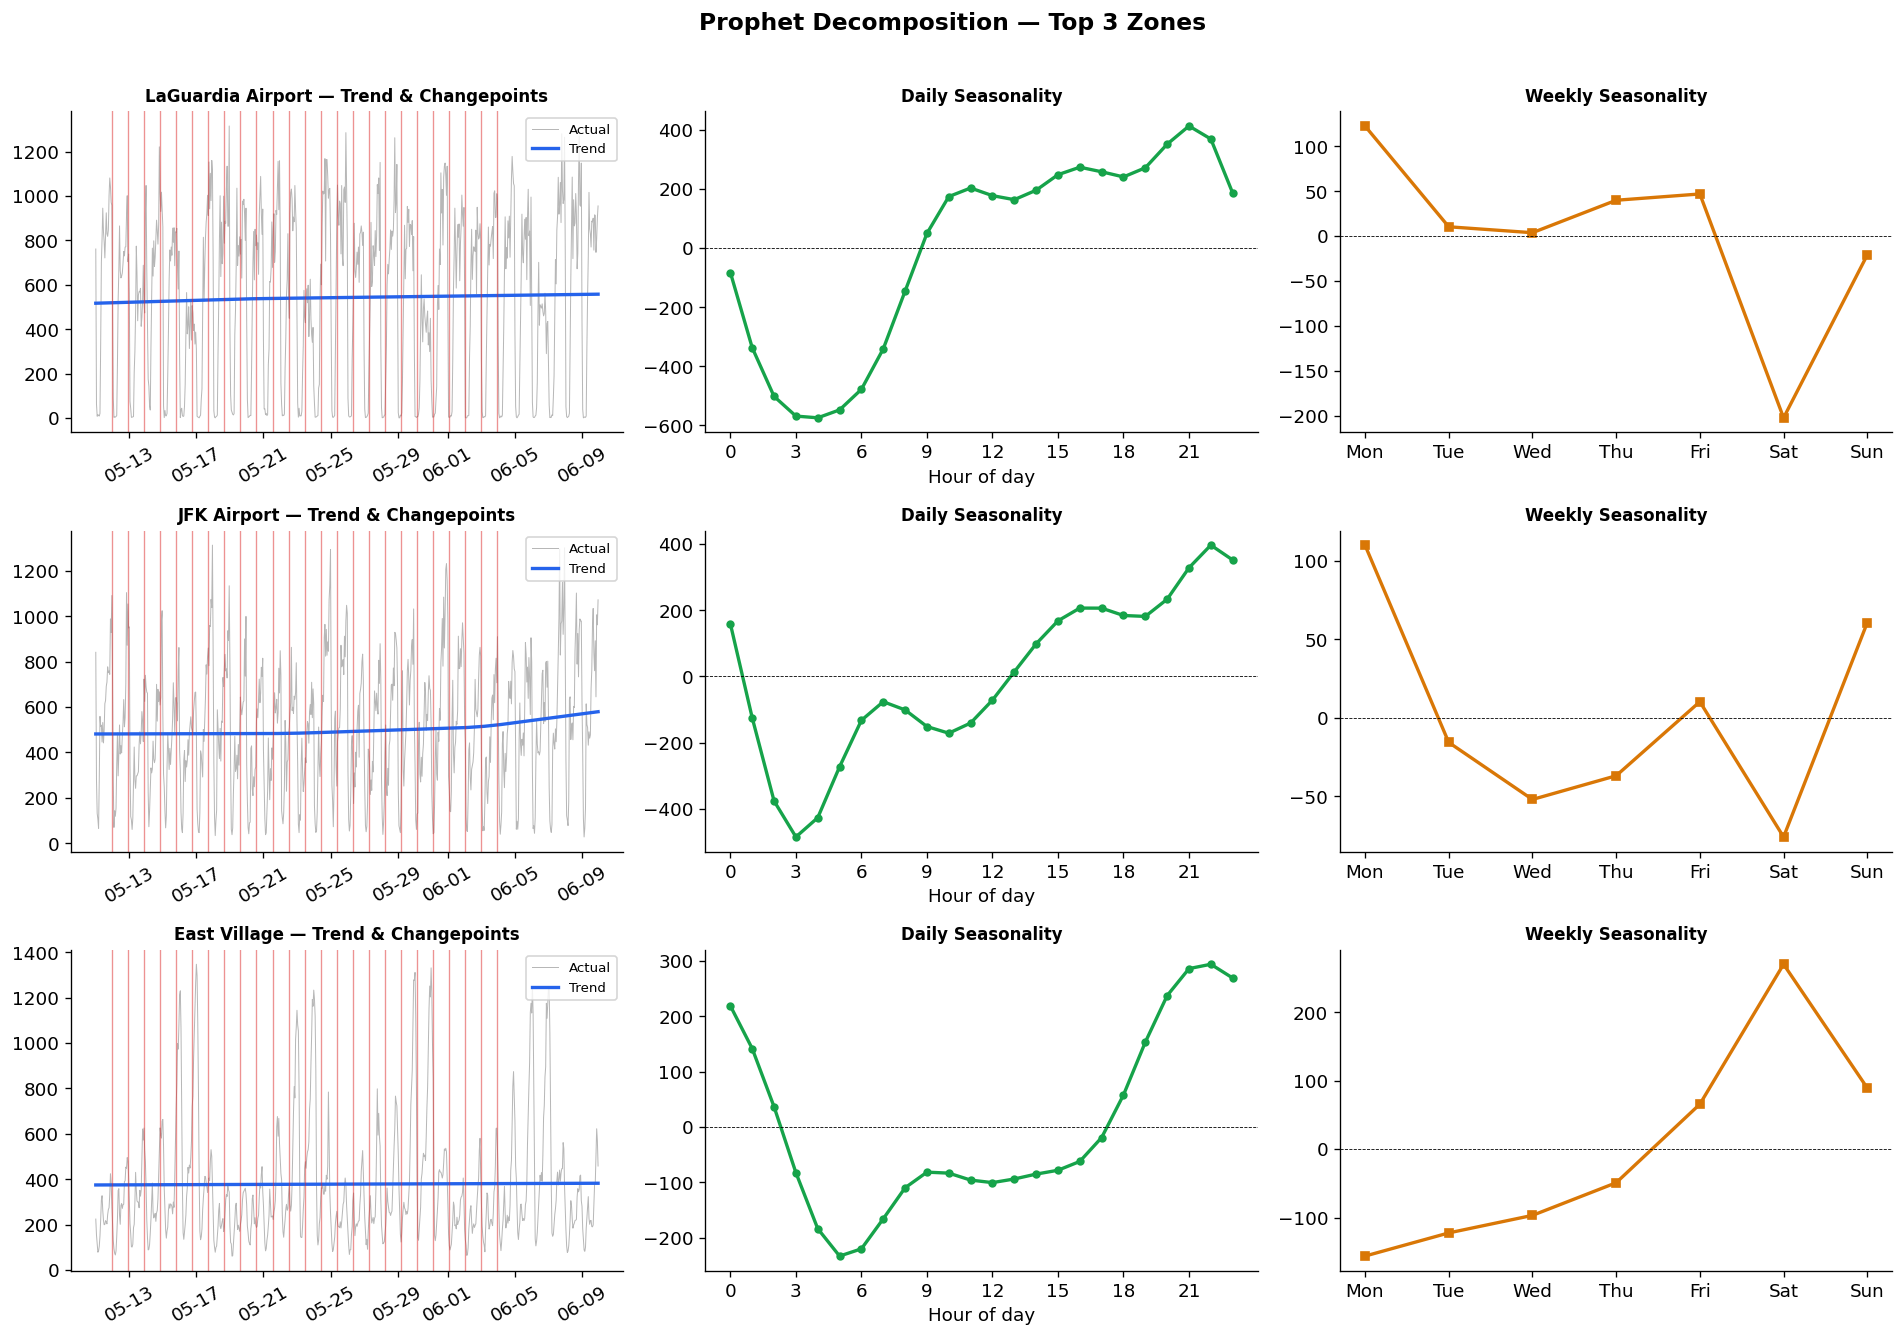

In [17]:
top3 = wide.sum().nlargest(3).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for row, zid in enumerate(top3):
    name = top_zones.loc[top_zones.zone_id == zid, 'zone_name'].iloc[0]
    z = decomp_df[decomp_df['zone_id'] == zid].copy()
    if not len(z):
        continue
    z = z.sort_values('analysis_time')

    # ── Col 0: actual + trend + changepoints ────────────────
    ax = axes[row, 0]
    actual = wide[zid]
    ax.plot(actual.index, actual.values, color='#888', lw=0.6, alpha=0.6, label='Actual')
    ax.plot(z['analysis_time'], z['trend_value'], color=PALETTE[0], lw=2, label='Trend')
    cps = z[z['changepoint_detected']]
    for _, cp in cps.iterrows():
        ax.axvline(cp['analysis_time'], color=PALETTE[2], lw=0.8, alpha=0.5)
    ax.set_title(f'{name} — Trend & Changepoints', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    # ── Col 1: daily seasonality (hour-of-day pattern) ──────
    ax = axes[row, 1]
    z['hour'] = pd.to_datetime(z['analysis_time']).dt.hour
    daily_pat = z.groupby('hour')['seasonal_daily'].mean()
    ax.plot(daily_pat.index, daily_pat.values, color=PALETTE[1], lw=2, marker='o', ms=4)
    ax.axhline(0, color='black', lw=0.5, linestyle='--')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel('Hour of day')
    ax.set_title('Daily Seasonality', fontsize=10, fontweight='bold')

    # ── Col 2: weekly seasonality (day-of-week pattern) ─────
    ax = axes[row, 2]
    z['dow'] = pd.to_datetime(z['analysis_time']).dt.dayofweek
    weekly_pat = z.groupby('dow')['seasonal_weekly'].mean()
    ax.plot(weekly_pat.index, weekly_pat.values, color=PALETTE[3], lw=2, marker='s', ms=5)
    ax.axhline(0, color='black', lw=0.5, linestyle='--')
    ax.set_xticks(range(7))
    ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    ax.set_title('Weekly Seasonality', fontsize=10, fontweight='bold')

plt.suptitle('Prophet Decomposition — Top 3 Zones', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/temporal/02_prophet_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

## 6 · Write to PostgreSQL

In [18]:
create_anom_sql = """
CREATE TABLE IF NOT EXISTS temporal_anomalies (
    id              BIGSERIAL,
    detected_at     TIMESTAMPTZ NOT NULL,
    zone_id         INTEGER REFERENCES taxi_zones(zone_id),
    anomaly_type    VARCHAR(30),
    anomaly_score   FLOAT,
    demand_value    FLOAT,
    expected_value  FLOAT,
    is_anomaly      BOOLEAN,
    PRIMARY KEY (id, detected_at)
);
SELECT create_hypertable('temporal_anomalies', 'detected_at',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
CREATE INDEX IF NOT EXISTS idx_temp_anom_zone
    ON temporal_anomalies (zone_id, detected_at DESC);

CREATE TABLE IF NOT EXISTS trend_decomposition (
    id                      BIGSERIAL,
    analysis_time           TIMESTAMPTZ NOT NULL,
    zone_id                 INTEGER REFERENCES taxi_zones(zone_id),
    trend_value             FLOAT,
    seasonal_daily          FLOAT,
    seasonal_weekly         FLOAT,
    changepoint_detected    BOOLEAN,
    holiday_effect          FLOAT,
    residual                FLOAT,
    PRIMARY KEY (id, analysis_time)
);
SELECT create_hypertable('trend_decomposition', 'analysis_time',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
CREATE INDEX IF NOT EXISTS idx_trend_zone
    ON trend_decomposition (zone_id, analysis_time DESC);
"""
with engine.connect() as conn:
    for stmt in create_anom_sql.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print('Hypertables ready: temporal_anomalies, trend_decomposition')

Hypertables ready: temporal_anomalies, trend_decomposition


In [19]:
# Write anomalies
if len(anom_df):
    anom_out = anom_df[['detected_at','zone_id','anomaly_type','anomaly_score',
                         'demand_value','expected_value','is_anomaly']].copy()
    anom_out['zone_id'] = anom_out['zone_id'].astype('int64')
    anom_out.to_sql('temporal_anomalies', engine, if_exists='append', index=False)
    print(f'Written {len(anom_out):,} anomaly rows.')
else:
    print('No anomalies to write.')

# Write decomposition
if len(decomp_df):
    decomp_out = decomp_df.copy()
    decomp_out['zone_id'] = decomp_out['zone_id'].astype('int64')
    decomp_out.to_sql('trend_decomposition', engine, if_exists='append', index=False)
    print(f'Written {len(decomp_out):,} decomposition rows.')

Written 192 anomaly rows.
Written 7,200 decomposition rows.


## 7 · Summary Findings

In [20]:
print('=' * 60)
print('TEMPORAL ANALYSIS SUMMARY FINDINGS')
print('=' * 60)

if len(anom_df):
    by_type   = anom_df['anomaly_type'].value_counts()
    most_anom = anom_df['zone_id'].value_counts().head(1)
    most_anom_zone = top_zones.loc[top_zones.zone_id == most_anom.index[0], 'zone_name'].iloc[0]
else:
    by_type = pd.Series(dtype=int)
    most_anom_zone = 'N/A'

if len(decomp_df):
    cps_per_zone = decomp_df.groupby('zone_id')['changepoint_detected'].sum().sort_values(ascending=False)
    most_unstable = top_zones.loc[top_zones.zone_id == cps_per_zone.index[0], 'zone_name'].iloc[0]
    avg_holiday   = decomp_df[decomp_df['holiday_effect'] != 0]['holiday_effect'].mean()
else:
    most_unstable = 'N/A'
    avg_holiday = 0

print(f"""
1. ADTK ANOMALIES:
   Total detected:    {len(anom_df):,}
   By type:
     {by_type.to_string().replace(chr(10), chr(10) + '     ')}
   Most-flagged zone: {most_anom_zone}

2. PROPHET DECOMPOSITION:
   Zones decomposed:        {decomp_df['zone_id'].nunique() if len(decomp_df) else 0}
   Total hours:             {len(decomp_df):,}
   Most trend-unstable:     {most_unstable} (most changepoints)
   Avg holiday impact:      {avg_holiday:+.1f} pickups/hour on holiday hours

3. OUTPUT FILES:
   outputs/temporal/01_adtk_anomalies.png
   outputs/temporal/02_prophet_decomposition.png

4. DB TABLES:
   temporal_anomalies   ({len(anom_df):,} rows)
   trend_decomposition  ({len(decomp_df):,} rows)
""")

TEMPORAL ANALYSIS SUMMARY FINDINGS

1. ADTK ANOMALIES:
   Total detected:    192
   By type:
     anomaly_type
     seasonal_deviation    181
     drop                   10
     spike                   1
   Most-flagged zone: Midtown Center

2. PROPHET DECOMPOSITION:
   Zones decomposed:        10
   Total hours:             7,200
   Most trend-unstable:     Crown Heights North (most changepoints)
   Avg holiday impact:      +26.8 pickups/hour on holiday hours

3. OUTPUT FILES:
   outputs/temporal/01_adtk_anomalies.png
   outputs/temporal/02_prophet_decomposition.png

4. DB TABLES:
   temporal_anomalies   (192 rows)
   trend_decomposition  (7,200 rows)



In [21]:
import os, shutil
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=False)

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1

print(f'Synced {n} files to {DRIVE_OUTPUTS}')

Mounted at /content/drive
Synced 2 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs
